In [3]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import HistGradientBoostingRegressor
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
import seaborn as sns
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import QuantileTransformer

In [4]:
# Load cleaned data
df = pd.read_csv('steam_ml_cleaned_data.csv').dropna()

# X: features (skipping first 3), y: target
X = df.iloc[:, 3:-1].copy()
y = df.iloc[:, -1]

# split into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

# create histboost regressor with early stopping
hgb = HistGradientBoostingRegressor(
    random_state=1,
    early_stopping=True,
    n_iter_no_change=15,
    validation_fraction=0.1
)

# create parameter distribution to use with search for HGBR
param_distributions = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_iter': [100, 300, 500],
    'max_depth': [3, 5, 10, None],
    'l2_regularization': [0, 0.1, 1.0],
    'min_samples_leaf': [10, 25, 50]
}

# define scoring metrics for HGBR
scoring = {
    'R2': 'r2',
    'MAE': 'neg_mean_absolute_error',
    'MSE': 'neg_mean_squared_error'
}

# implement random search for histboost regressor with parameter distribution
# and five fold cross validation using scoring metrics with refit metric r2
random_search = RandomizedSearchCV(
    estimator=hgb,
    param_distributions=param_distributions,
    n_iter=40,                       
    scoring=scoring,
    cv=5,
    refit='R2',
    n_jobs=-1,
    verbose=1,
    random_state=21
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",HistGradientB...andom_state=1)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'l2_regularization': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'max_iter': [100, 300, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",40
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'MAE': 'neg_mean_absolute_error', 'MSE': 'neg_mean_squared_error', 'R2': 'r2'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'R2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User 

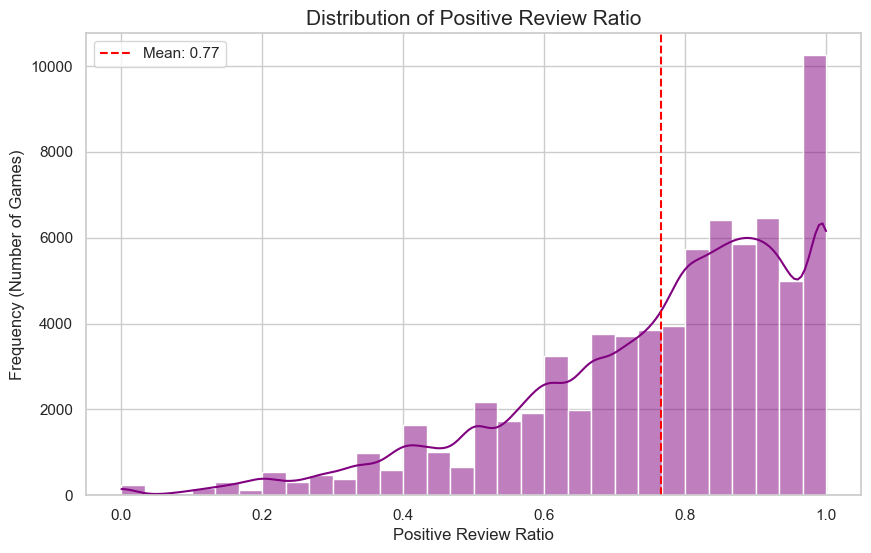

Top Five Parameter Combinations:


,params,rank_test_R2,mean_test_R2,std_test_R2,mean_test_MAE,std_test_MAE,mean_test_MSE,std_test_MSE
33,"{'min_samples_leaf': 50, 'max_iter': 500, 'max_depth': 10, 'learning_rate': 0.05, 'l2_regularization': 0.1}",1,0.321532,0.005634,-0.123484,0.000734,-0.026646,0.000318
27,"{'min_samples_leaf': 25, 'max_iter': 500, 'max_depth': None, 'learning_rate': 0.05, 'l2_regularization': 0.1}",2,0.320093,0.005891,-0.123633,0.000876,-0.026703,0.000340
14,"{'min_samples_leaf': 25, 'max_iter': 500, 'max_depth': 10, 'learning_rate': 0.05, 'l2_regularization': 1.0}",3,0.319849,0.005386,-0.123774,0.000722,-0.026712,0.000308
24,"{'min_samples_leaf': 25, 'max_iter': 500, 'max_depth': None, 'learning_rate': 0.1, 'l2_regularization': 0}",4,0.319108,0.006254,-0.123710,0.000963,-0.026742,0.000389
34,"{'min_samples_leaf': 25, 'max_iter': 500, 'max_depth': 10, 'learning_rate': 0.05, 'l2_regularization': 0}",5,0.319100,0.005612,-0.123787,0.000927,-0.026742,0.000346


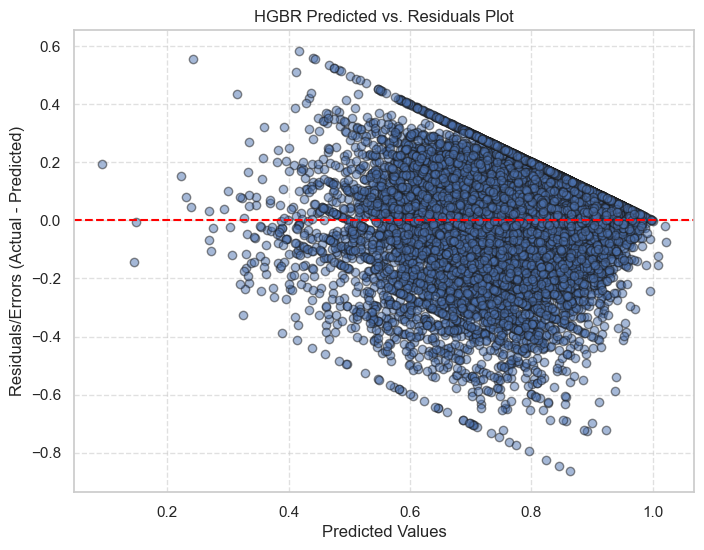

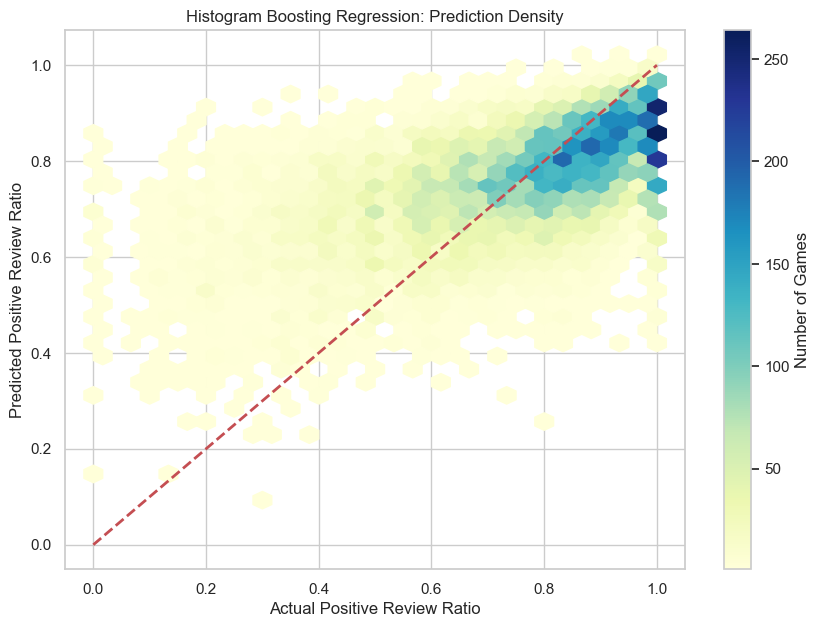

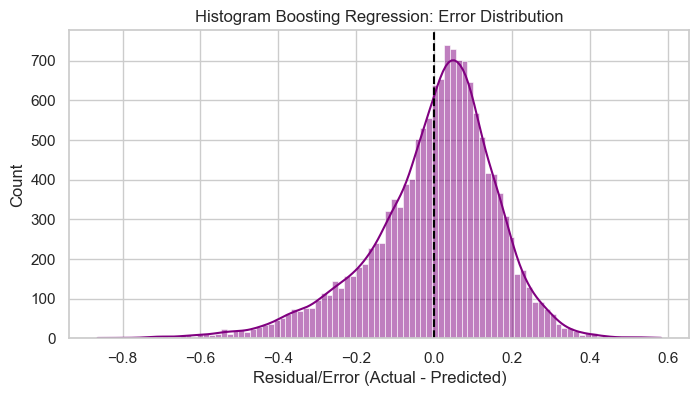

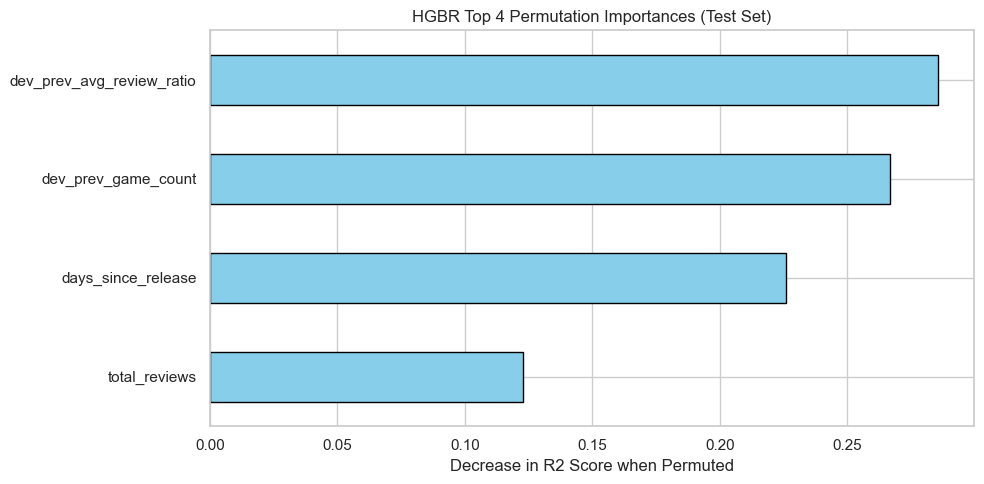

c:\Users\evans\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 16 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
c:\Users\evans\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 2 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


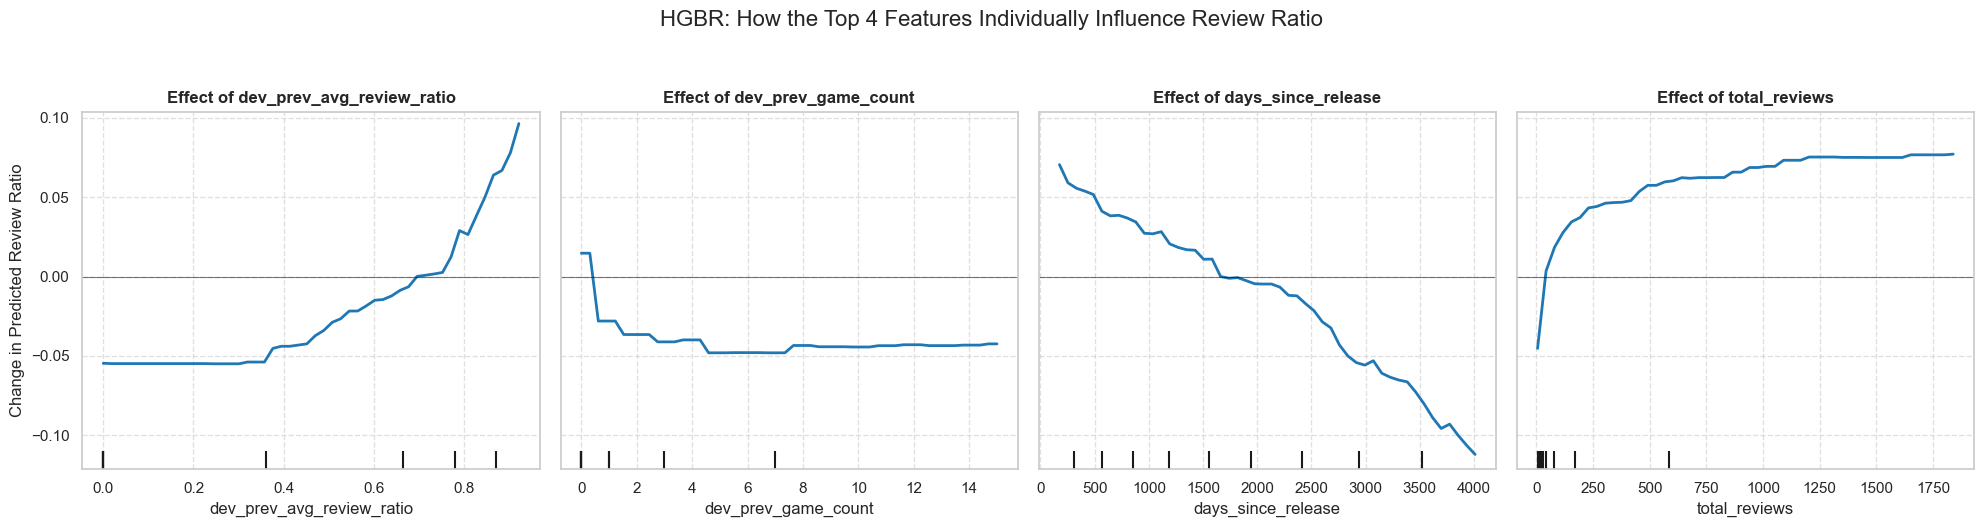

In [ ]:
# Plotting the distribution of the target variable (y_train)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(y, kde=True, color='purple', bins=30)
plt.title('Distribution of Positive Review Ratio', fontsize=15)
plt.xlabel('Positive Review Ratio', fontsize=12)
plt.ylabel('Frequency (Number of Games)', fontsize=12)
plt.axvline(y.mean(), color='red', linestyle='--', label=f'Mean: {y.mean():.2f}')
plt.legend()
plt.show()


# Results Table for Parameters
results_df = pd.DataFrame(random_search.cv_results_)
relevant_columns = ['params', 'rank_test_R2']
score_cols = ['mean_test_R2', 'std_test_R2', 'mean_test_MAE', 'std_test_MAE', 
              'mean_test_MSE', 'std_test_MSE']
relevant_columns.extend(score_cols)
display_table = results_df[relevant_columns].sort_values('rank_test_R2')
print("Top Five Parameter Combinations:")
pd.set_option('display.max_colwidth', None)
display(display_table.head())

# Predicted vs Residuals Graph
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.5, edgecolors='k')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals/Errors (Actual - Predicted)')
plt.title('HGBR Predicted vs. Residuals Plot')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

def plot_prediction_analysis(y_true, y_pred, model_name="Model"):
    """
    Hexbin density plot and the Residual distribution.
    """
    #hexbin plot
    plt.figure(figsize=(10, 7))
    hb = plt.hexbin(y_true, y_pred, gridsize=30, cmap='YlGnBu', mincnt=1)
    plt.colorbar(hb, label='Number of Games')
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    plt.title(f'{model_name}: Prediction Density')
    plt.xlabel('Actual Positive Review Ratio')
    plt.ylabel('Predicted Positive Review Ratio')
    plt.show()

    #residual plot
    residuals = y_true - y_pred
    plt.figure(figsize=(8, 4))
    sns.histplot(residuals, kde=True, color='purple')
    plt.axvline(0, color='black', linestyle='--')
    plt.title(f'{model_name}: Error Distribution')
    plt.xlabel('Residual/Error (Actual - Predicted)')
    plt.show()

plot_prediction_analysis(y_test, y_pred, "Histogram Boosting Regression")

# top four feature importance bar graph (permutation-based)
feature_names = X.columns.tolist()
perm_importance = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=7)

importances = pd.Series(perm_importance.importances_mean, index=feature_names)
sorted_importances = importances.sort_values()
top_4_importances = sorted_importances.tail(4)
top_4_importances.plot(
    kind='barh', 
    title='HGBR Top 4 Permutation Importances (Test Set)',
    figsize=(10, 5),
    color='skyblue',
    edgecolor='black'
)
plt.xlabel("Decrease in R2 Score when Permuted")
plt.tight_layout()
plt.show()
top_4_features = top_4_importances.sort_values(ascending=False).index.tolist()

# create partial dependence plots for top features
def create_partial_dependence_plot_top_features(top_features, model, X_train, title):
    fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

    display1d = PartialDependenceDisplay.from_estimator(
        model, 
        X_train, 
        features=top_features,
        feature_names=X.columns.tolist(), 
        ax=axes,
        grid_resolution=50,
        line_kw={"color": "tab:blue", "linewidth": 2}
    )
    # plot partial dependence plots with labels
    for i, ax in enumerate(axes):
        ax.set_title(f'Effect of {top_features[i]}', fontsize=12, fontweight='bold')
        ax.set_ylabel('Change in Predicted Review Ratio' if i==0 else "")
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)
    plt.suptitle(title, fontsize=16, y=1.05)
    plt.tight_layout()
    plt.show()

create_partial_dependence_plot_top_features(top_4_features, best_model, X_train,
                            'HGBR: How the Top 4 Features Individually Influence Review Ratio')